              Dataset  Grammarly (%)  GPTZero (%)  ZeroGPT (%)  \
0               GPT-2             20           35           12   
1               GPT-3             52           96           86   
2              GPT-4o             98           97           96   
3  GPT-4o with emojis             29           74           91   
4               Human              3            1            4   

   Grammarly (count)  GPTZero (count)  ZeroGPT (count)  
0               40.0             70.0             24.0  
1              104.0            192.0            172.0  
2              196.0            194.0            192.0  
3               58.0            148.0            182.0  
4               24.0              8.0             32.0  
Grammarly results:
{'TP': np.float64(398.0), 'FP': np.float64(24.0), 'TN': np.float64(776.0), 'FN': np.float64(402.0)}
GPTZero results:
{'TP': np.float64(604.0), 'FP': np.float64(8.0), 'TN': np.float64(792.0), 'FN': np.float64(196.0)}
ZeroGPT results:
{'TP': np

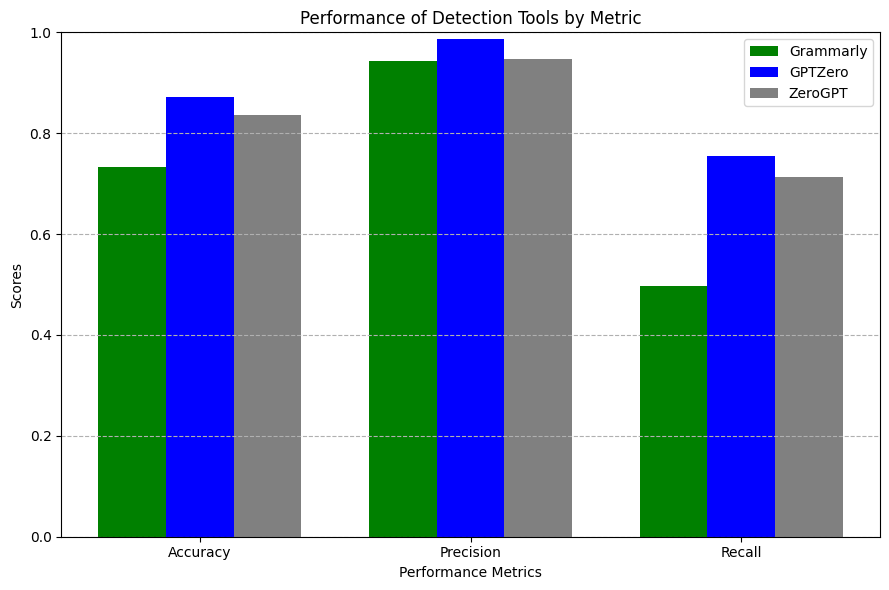

In [1]:
## PERFORMANCE METRICS FOR AI DETECTION TOOLS ##


import pandas as pd
import numpy as np
# Total tweets per dataset
tweet_counts = {
    "GPT-2": 200,
    "GPT-3": 200,
    "GPT-4o": 200,
    "GPT-4o with emojis": 200,
    "Human": 800
}

# Raw results in percentages
results = {
    "Dataset": ["GPT-2", "GPT-3", "GPT-4o", "GPT-4o with emojis", "Human"],
    "Grammarly (%)": [20, 52, 98, 29, 3],
    "GPTZero (%)": [35, 96, 97, 74, 1],
    "ZeroGPT (%)": [12, 86, 96, 91, 4]
}

# Create DataFrame
df = pd.DataFrame(results)

# Convert percentages to numbers based on tweet counts
for tool in ["Grammarly (%)", "GPTZero (%)", "ZeroGPT (%)"]:
    df[tool.replace("(%)", "(count)")] = df.apply(lambda row: (row[tool] / 100) * tweet_counts[row["Dataset"]], axis=1)

print(df)

# Calculate TP, FP, TN, FN per tool
metrics = {}
tools = ["Grammarly", "GPTZero", "ZeroGPT"]

for tool in tools:
    ai_detected = df.loc[df["Dataset"] != "Human", f"{tool} (count)"].sum()
    human_detected = df.loc[df["Dataset"] == "Human", f"{tool} (count)"].values[0]

    TP = ai_detected
    FN = 800 - ai_detected  # total AI tweets = 200 * 4 = 800
    FP = human_detected
    TN = 800 - human_detected  # total Human tweets = 800

    metrics[tool] = {"TP": TP, "FP": FP, "TN": TN, "FN": FN}

# Display results
for tool, metric_values in metrics.items():
    print(f"{tool} results:")
    print(metric_values)
# Results per tool
results = {
    'Grammarly': {'TP': 398, 'FP': 24, 'TN': 776, 'FN': 402},
    'GPTZero': {'TP': 604, 'FP': 8, 'TN': 792, 'FN': 196},
    'ZeroGPT': {'TP': 570, 'FP': 32, 'TN': 768, 'FN': 230}
}

# Define functions to calculate metrics
def calculate_metrics(TP, FP, TN, FN):
    accuracy = (TP + TN) / (TP + FP + TN + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    false_positive_rate = FP / (FP + TN) if (FP + TN) != 0 else 0
    false_negative_rate = FN / (FN + TP) if (FN + TP) != 0 else 0
    return accuracy, precision, recall, false_positive_rate, false_negative_rate

# Calculate metrics for each tool
metrics_summary = []

for tool, vals in results.items():
    accuracy, precision, recall, fpr, fnr = calculate_metrics(
        vals['TP'], vals['FP'], vals['TN'], vals['FN']
    )
    metrics_summary.append({
        'Tool': tool,
        'Accuracy': round(accuracy, 3),
        'Precision': round(precision, 3),
        'Recall (Sensitivity)': round(recall, 3),
        'False Positive Rate': round(fpr, 3),
        'False Negative Rate': round(fnr, 3)
    })

# Display results in a DataFrame
metrics_df = pd.DataFrame(metrics_summary)
print(metrics_df)

#### Visusualization of the results ###
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics and scores for each tool
metrics = ['Accuracy', 'Precision', 'Recall']
grammarly = [0.73375, 0.9431, 0.4975]
gptzero = [0.8725, 0.9869, 0.7550]
zerogpt = [0.83625, 0.9468, 0.7125]

# Set position for each metric group
x = np.arange(len(metrics))
width = 0.25  # Width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(9, 6))

# Plot bars for each tool
ax.bar(x - width, grammarly, width, label='Grammarly', color='green')
ax.bar(x, gptzero, width, label='GPTZero', color='blue')
ax.bar(x + width, zerogpt, width, label='ZeroGPT', color='gray')

# Add labels and formatting
ax.set_xlabel('Performance Metrics')
ax.set_ylabel('Scores')
ax.set_title('Performance of Detection Tools by Metric')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

# Add gridlines for better readability
ax.grid(axis='y', linestyle='--')

# Improve layout
plt.tight_layout()
plt.show()


Converted Counts per Dataset:
              Dataset  Grammarly (count)  GPTZero (count)  ZeroGPT (count)
0               GPT-2               40.0             70.0             24.0
1               GPT-3              104.0            192.0            172.0
2              GPT-4o              196.0            194.0            192.0
3  GPT-4o with emojis               58.0            148.0            182.0
4               Human               24.0              8.0             32.0

Performance Metrics per Dataset and Tool:
               Dataset       Tool  Accuracy  Precision  Recall  \
0                GPT-2  Grammarly      0.20        1.0    0.20   
1                GPT-2    GPTZero      0.35        1.0    0.35   
2                GPT-2    ZeroGPT      0.12        1.0    0.12   
3                GPT-3  Grammarly      0.52        1.0    0.52   
4                GPT-3    GPTZero      0.96        1.0    0.96   
5                GPT-3    ZeroGPT      0.86        1.0    0.86   
6              

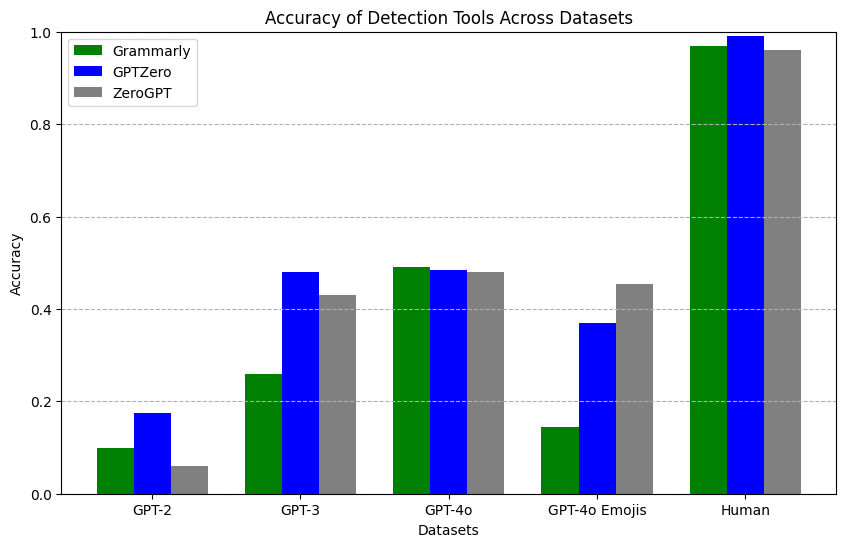

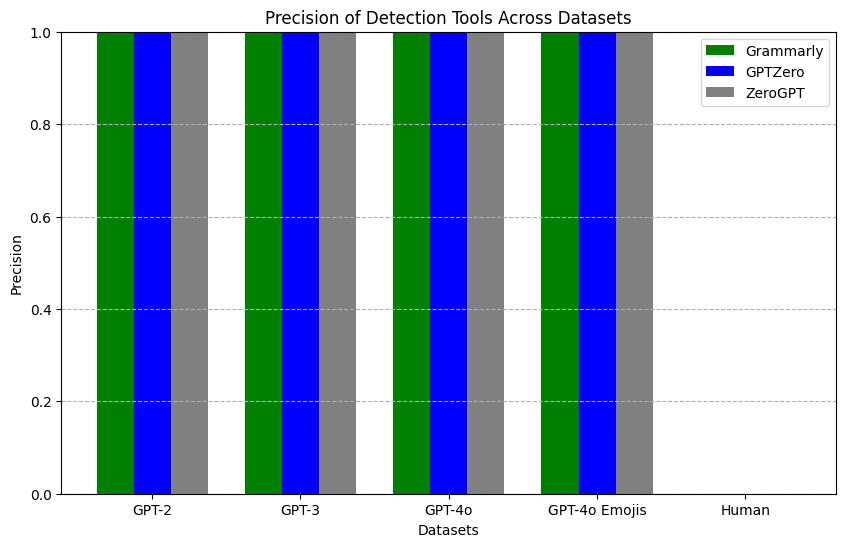

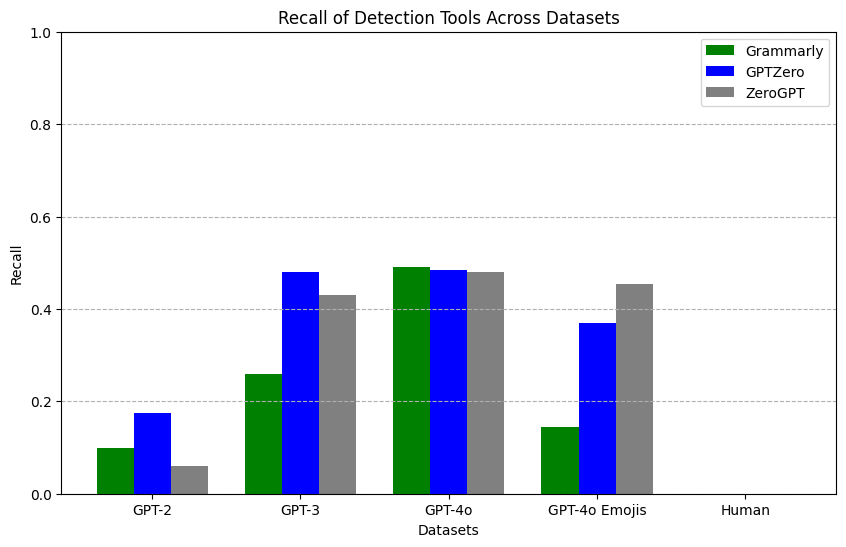

In [2]:
### Performance Metrics for Datasets ###

import pandas as pd

# Total tweets per dataset
tweet_counts = {
    "GPT-2": 200,
    "GPT-3": 200,
    "GPT-4o": 200,
    "GPT-4o with emojis": 200,
    "Human": 800
}

# Raw results in percentages
results = {
    "Dataset": ["GPT-2", "GPT-3", "GPT-4o", "GPT-4o with emojis", "Human"],
    "Grammarly (%)": [20, 52, 98, 29, 3],
    "GPTZero (%)": [35, 96, 97, 74, 1],
    "ZeroGPT (%)": [12, 86, 96, 91, 4]
}

# Create DataFrame
df = pd.DataFrame(results)

# Convert percentages to numeric counts
for tool in ["Grammarly (%)", "GPTZero (%)", "ZeroGPT (%)"]:
    df[tool.replace("(%)", "(count)")] = df.apply(lambda row: (row[tool] / 100) * tweet_counts[row["Dataset"]], axis=1)

# Display intermediate results
print("Converted Counts per Dataset:")
print(df[['Dataset', 'Grammarly (count)', 'GPTZero (count)', 'ZeroGPT (count)']])

# Define function to calculate metrics per dataset
def calculate_metrics_dataset(predicted_ai, actual_ai, total_tweets):
    TP = predicted_ai if actual_ai else 0
    FP = predicted_ai if not actual_ai else 0
    FN = total_tweets - predicted_ai if actual_ai else 0
    TN = total_tweets - predicted_ai if not actual_ai else 0
    
    accuracy = (TP + TN) / total_tweets
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) != 0 else 0
    
    return accuracy, precision, recall, fpr, fnr

# Calculate metrics per dataset, per tool
tools = ["Grammarly (count)", "GPTZero (count)", "ZeroGPT (count)"]
datasets = df["Dataset"]

# Human-generated dataset is "Human"
actual_ai_datasets = ["GPT-2", "GPT-3", "GPT-4o", "GPT-4o with emojis"]

metrics_result = []

for dataset in datasets:
    total = tweet_counts[dataset]
    actual_ai = dataset in actual_ai_datasets
    for tool in tools:
        pred_ai = df.loc[df["Dataset"] == dataset, tool].values[0]
        accuracy, precision, recall, fpr, fnr = calculate_metrics_dataset(pred_ai, actual_ai, total)
        metrics_result.append({
            "Dataset": dataset,
            "Tool": tool.replace(" (count)", ""),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "False Positive Rate": fpr,
            "False Negative Rate": fnr
        })

# Convert results to DataFrame for clarity
df_metrics = pd.DataFrame(metrics_result)

# Display final results
print("\nPerformance Metrics per Dataset and Tool:")
print(df_metrics)


import matplotlib.pyplot as plt
import numpy as np
# Datasets and tools
datasets = ['GPT-2', 'GPT-3', 'GPT-4o', 'GPT-4o Emojis', 'Human']
tools = ['Grammarly', 'GPTZero', 'ZeroGPT']

# Metrics data
accuracy = np.array([
    [0.10, 0.26, 0.49, 0.145, 0.97],   # Grammarly
    [0.175, 0.48, 0.485, 0.37, 0.99],  # GPTZero
    [0.06, 0.43, 0.48, 0.455, 0.96]    # ZeroGPT
])

precision = np.array([
    [1, 1, 1, 1, 0],  # Grammarly
    [1, 1, 1, 1, 0],  # GPTZero
    [1, 1, 1, 1, 0]   # ZeroGPT
])

recall = np.array([
    [0.10, 0.26, 0.49, 0.145, 0],      # Grammarly
    [0.175, 0.48, 0.485, 0.37, 0],     # GPTZero
    [0.06, 0.43, 0.48, 0.455, 0]       # ZeroGPT
])

# Function to create bar plots
def plot_metric(metric, metric_name):
    x = np.arange(len(datasets))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(x - width, metric[0], width, label='Grammarly', color='green')
    bars2 = ax.bar(x, metric[1], width, label='GPTZero', color = 'blue')
    bars3 = ax.bar(x + width, metric[2], width, label='ZeroGPT', color='gray')

    ax.set_xlabel('Datasets')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} of Detection Tools Across Datasets')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.legend()
    ax.grid(axis='y', linestyle='--')

    plt.ylim(0, 1)
    plt.show()

# Plot each metric
plot_metric(accuracy, 'Accuracy')
plot_metric(precision, 'Precision')
plot_metric(recall, 'Recall')